# GA4 E-Commerce Funnel Analyse

**Dataset:** `bigquery-public-data.ga4_obfuscated_sample_ecommerce`  
**Ziel:** Den Kaufprozess von der ersten Interaktion bis zum Kauf verstehen und Optimierungspotenziale identifizieren.

---

## Struktur des Notebooks


1. Setup & Analysezeitraum
2. Dataset-Überblick
3. Event Inventory ## Was passiert überhaupt?
4. Standard E-Commerce Funnel (Event-Level)
5. User-Level Funnel ## Wie viele User schließen jeden Schritt ab?
6. Drop-off Analyse ## Wo werden die meisten User verloren?
7. Segmentierung ## Gibt es unterschiede bei den Geräten?
8. Revenue-Analyse
9. Visualisierungen
10. Zusammenfassung


## 1. Setup

In [2]:
#%pip install --upgrade bigframes matplotlib
import bigframes.pandas as bpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

PROJECT_ID = "funnel-analysis-demo-491115"
LOCATION = "eu"

DATE_START = '20210101'
DATE_END   = '20210131'

pd.set_option('display.max_rows', 20)

print(f"Analysezeitraum: {DATE_START} – {DATE_END}")

Analysezeitraum: 20210101 – 20210131


## 2. Dataset-Überblick

Verschaffen eines Überblicks

In [3]:
df_overview = bpd.read_gbq(f"""
SELECT
  COUNT(*)                        AS total_events,
  COUNT(DISTINCT user_pseudo_id)  AS unique_users,
  COUNT(DISTINCT event_date)      AS days_in_dataset,
  MIN(event_date)                 AS first_day,
  MAX(event_date)                 AS last_day
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
""")

df_overview.head(1)

,total_events,unique_users,days_in_dataset,first_day,last_day
0,1210147,94790,31,20210101,20210131


## 3. Event Inventory

Welche Events gibt es überhaupt?

In [4]:
df_events = bpd.read_gbq(f"""
SELECT
  event_name,
  COUNT(*)                        AS event_count,
  COUNT(DISTINCT user_pseudo_id)  AS unique_users,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage_of_all_events
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY event_name
""")


df_events = df_events.sort_values(by='event_count', ascending=False)
df_events.head(20).to_pandas()

,event_name,event_count,unique_users,percentage_of_all_events
8,page_view,419004,94630,34.62
6,user_engagement,250097,72574,20.67
5,scroll,138997,45594,11.49
11,session_start,116549,93552,9.63
1,first_visit,88873,88830,7.34
16,view_item,86971,19629,7.19
10,view_promotion,53885,32131,4.45
4,add_to_cart,15522,3832,1.28
0,begin_checkout,11034,1924,0.91
14,select_item,10229,4991,0.85


## 4. Standard E-Commerce Funnel

Der klassische GA4 E-Commerce Funnel:

```
view_item            (Produktseite angesehen)
    → add_to_cart      (Produkt in den Warenkorb)
        → begin_checkout      (Checkout gestartet)
            → add_shipping_info   (Versandinfos eingegeben)
                → add_payment_info  (Zahlungsmethode gewählt)
                    → purchase        (Kauf abgeschlossen)
```

Warum starte ich nicht mit Page view? Weil Page_View kein klares Kaufsignal ist und bei jedem Seitenbesuch ausgelöst wird, da ist zu viel "Noise" das auch die Kaufconversion küsntlich verschlechtert.

Ich sehe das erste Kaufsignal klar wenn der Nutzer eine Produktseite öffnet.

Für die Analyse ist jetzt wichtig wie oft jeder Schritt geschieht?

In [27]:
FUNNEL_STEPS = [
    'view_item',
    'add_to_cart',
    'begin_checkout',
    'add_shipping_info',
    'add_payment_info',
    'purchase'
]

df_funnel_events = bpd.read_gbq(f"""
    SELECT
      event_name,
      COUNT(*) AS event_count
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
      AND event_name IN (
        'view_item', 'add_to_cart',
        'begin_checkout', 'add_shipping_info',
        'add_payment_info', 'purchase'
      )
    GROUP BY event_name
""")

df_funnel_events = (
    df_funnel_events
    .to_pandas()
    .set_index('event_name')
    .reindex(FUNNEL_STEPS)
    .reset_index()
)

df_funnel_events

,event_name,event_count
0,view_item,86971
1,add_to_cart,15522
2,begin_checkout,11034
3,add_shipping_info,3952
4,add_payment_info,2841
5,purchase,1204


## 5. User-Level Funnel 

Event-Counts können täuschen (ein User kann `view_item` 50x auslösen), deswegen die Frage: "Wie viele eindeutige User erreichen jeden Schritt?"  

In [28]:
df_user_funnel = bpd.read_gbq(f"""
SELECT
  COUNT(DISTINCT IF(event_name = 'view_item',         user_pseudo_id, NULL)) AS view_item,
  COUNT(DISTINCT IF(event_name = 'add_to_cart',       user_pseudo_id, NULL)) AS add_to_cart,
  COUNT(DISTINCT IF(event_name = 'begin_checkout',    user_pseudo_id, NULL)) AS begin_checkout,
  COUNT(DISTINCT IF(event_name = 'add_shipping_info', user_pseudo_id, NULL)) AS add_shipping_info,
  COUNT(DISTINCT IF(event_name = 'add_payment_info',  user_pseudo_id, NULL)) AS add_payment_info,
  COUNT(DISTINCT IF(event_name = 'purchase',          user_pseudo_id, NULL)) AS purchase
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  AND event_name IN (
    'view_item', 'add_to_cart', 'begin_checkout',
    'add_shipping_info', 'add_payment_info', 'purchase'
  )
""")

df_user_funnel = df_user_funnel.to_pandas().melt(var_name='step', value_name='users')

df_user_funnel

,step,users
0,view_item,19629
1,add_to_cart,3832
2,begin_checkout,1924
3,add_shipping_info,1924
4,add_payment_info,1395
5,purchase,1069


## 6. Drop-off Analyse

Jetzt berechnen wir:
- **`pct_of_start`** — wie viel % der initialen Session-User noch dabei sind
- **`step_conversion_pct`** — wie viel % der User des *vorherigen* Schritts weitergehen

> Ein niedriger `step_conversion_pct` zeigt, wo der größte Handlungsbedarf besteht.

In [29]:
df_dropoff = df_user_funnel.copy()

df_dropoff['pct_of_start']      = (df_dropoff['users'] / df_dropoff['users'].iloc[0] * 100).round(2)
df_dropoff['step_conversion_pct'] = (df_dropoff['users'] / df_dropoff['users'].shift(1) * 100).round(2)
df_dropoff['dropoff_users']     = df_dropoff['users'].shift(1) - df_dropoff['users']

df_dropoff

,step,users,pct_of_start,step_conversion_pct,dropoff_users
0,view_item,19629,100.0,<NA>,<NA>
1,add_to_cart,3832,19.52,19.52,15797
2,begin_checkout,1924,9.8,50.21,1908
3,add_shipping_info,1924,9.8,100.0,0
4,add_payment_info,1395,7.11,72.51,529
5,purchase,1069,5.45,76.63,326


## 7. Segmentierung 

Gibt es unterschied bei der Kaufconversion bei den unterschiedliche Geräten? (Tablet, Desktop, Mobile)

In [8]:
df_device = bpd.read_gbq(f"""
SELECT
  device.category                                                                AS device_category,
  COUNT(DISTINCT user_pseudo_id)                                                 AS sessions,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))              AS purchases,
  ROUND(COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL)) 
        * 100.0 / NULLIF(COUNT(DISTINCT user_pseudo_id), 0), 2)                 AS conversion_rate_pct
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY device.category
""")
df_device = df_device.sort_values(by='sessions', ascending=False)
df_device.to_pandas()

,device_category,sessions,purchases,conversion_rate_pct
1,desktop,55236,594,1.08
2,mobile,37934,450,1.19
0,tablet,2166,29,1.34


Welche 10 Länder haben die größte prozentuale Kaufconversion?

In [15]:
df_country = bpd.read_gbq(f"""
SELECT
  geo.country                                                                    AS country,
  COUNT(DISTINCT user_pseudo_id)                                                 AS sessions,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))              AS purchases,
  ROUND(COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))
        * 100.0 / NULLIF(COUNT(DISTINCT user_pseudo_id), 0), 2)                 AS conversion_rate_pct
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  AND geo.country IS NOT NULL
  AND geo.country != ''
GROUP BY geo.country
HAVING COUNT(DISTINCT user_pseudo_id) >= 100
LIMIT 10
""")

df_country = df_country.to_pandas().sort_values('conversion_rate_pct', ascending=False)
df_country

,country,sessions,purchases,conversion_rate_pct
6,Japan,1270,21,1.65
8,Philippines,502,8,1.59
5,Canada,7043,92,1.31
3,Brazil,949,12,1.26
0,France,1871,21,1.12
2,Ireland,518,5,0.97
7,Portugal,430,4,0.93
1,China,1600,14,0.88
4,Germany,1663,12,0.72
9,Switzerland,519,3,0.58


## 8. Revenue-Analyse — Was bringt der Funnel monetär?

Die Kaufconversion selber sagt noch nicht allzu viel aus, aufgrund der unterschiedlichen Umsätze der Kunden, deshalb wird darauf jetzt geschaut

In [17]:
df_revenue = bpd.read_gbq(f"""
SELECT
  COUNT(DISTINCT user_pseudo_id)          AS buying_users,
  COUNT(*)                                AS total_purchases,
  ROUND(SUM(p.value.double_value), 2)     AS total_revenue,
  ROUND(AVG(p.value.double_value), 2)     AS avg_order_value
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
CROSS JOIN UNNEST(event_params) AS p
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  AND event_name = 'purchase'
  AND p.key = 'value'
""")

df_revenue.to_pandas()


,buying_users,total_purchases,total_revenue,avg_order_value
0,819,904,41630.51,68.47


In [18]:
df_daily = bpd.read_gbq(f"""
SELECT
  event_date,
  COUNT(DISTINCT user_pseudo_id)      AS buying_users,
  ROUND(SUM(p.value.double_value), 2) AS daily_revenue,
  ROUND(AVG(p.value.double_value), 2) AS avg_order_value
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
CROSS JOIN UNNEST(event_params) AS p
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  AND event_name = 'purchase'
  AND p.key = 'value'
GROUP BY event_date
""")

df_daily = df_daily.to_pandas().sort_values('event_date').reset_index(drop=True)
df_daily

,event_date,buying_users,daily_revenue,avg_order_value
0,20210101,12,810.65,81.06
1,20210102,13,936.01,104.0
2,20210103,13,413.28,59.04
3,20210104,16,678.04,52.16
4,20210105,26,827.3,48.66
...,...,...,...,...
25,20210126,21,838.5,59.89
26,20210127,12,241.6,30.2
27,20210128,5,115.47,28.87
28,20210129,6,109.92,27.48


## 9. Visualisierungen

Jetzt bringen wir die Ergebnisse in Charts.

In [ ]:
import plotly.express as px

label_map = {
    'view_item':         'Produkt angesehen',
    'add_to_cart':       'In den Warenkorb',
    'begin_checkout':    'Checkout gestartet',
    'add_shipping_info': 'Versand eingegeben',
    'add_payment_info':  'Zahlung eingegeben',
    'purchase':          'Kauf abgeschlossen',
}

df_funnel_plot = df_user_funnel.copy()
df_funnel_plot['step'] = df_funnel_plot['step'].map(label_map)

fig = px.funnel_area(
    df_funnel_plot,
    values='users',
    names='step',
    title='E-Commerce Funnel – User-Level'
)

fig.update_layout(title_x=0.5)

fig.show()

In [ ]:
import plotly.graph_objects as go

# Nodes: Funnel-Schritte + Drop-off-Knoten pro Schritt
node_labels = [
    'Produkt angesehen',   # 0
    'In den Warenkorb',    # 1
    'Checkout gestartet',  # 2
    'Versand eingegeben',  # 3
    'Zahlung eingegeben',  # 4
    'Kauf abgeschlossen',  # 5
    'Drop-off',            # 6  (nach view_item)
    'Drop-off',            # 7  (nach add_to_cart)
    'Drop-off',            # 8  (nach add_shipping_info)
    'Drop-off',            # 9  (nach add_payment_info)
]

node_colors = [
    '#2a6ebb', '#2a6ebb', '#2a6ebb', '#2a6ebb', '#2a6ebb',  # Funnel-Schritte
    '#2ecc71',                                                # Kauf abgeschlossen
    '#e74c3c', '#e74c3c', '#e74c3c', '#e74c3c',              # Drop-offs
]

# Links: source → target, value
sources = [0, 0, 1, 1, 2, 3, 3, 4, 4]
targets = [1, 6, 2, 7, 3, 4, 8, 5, 9]
values  = [3832, 15797, 1924, 1908, 1924, 1395, 529, 1069, 326]

link_colors = [
    'rgba(42,110,187,0.4)',   # view_item → add_to_cart
    'rgba(231,76,60,0.4)',    # view_item → drop-off
    'rgba(42,110,187,0.4)',   # add_to_cart → begin_checkout
    'rgba(231,76,60,0.4)',    # add_to_cart → drop-off
    'rgba(42,110,187,0.4)',   # begin_checkout → add_shipping_info
    'rgba(42,110,187,0.4)',   # add_shipping_info → add_payment_info
    'rgba(231,76,60,0.4)',    # add_shipping_info → drop-off
    'rgba(46,204,113,0.4)',   # add_payment_info → purchase
    'rgba(231,76,60,0.4)',    # add_payment_info → drop-off
]

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        label=node_labels,
        color=node_colors,
        pad=20,
        thickness=25,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    )
))

fig.update_layout(
    title=dict(text='Funnel Drop-off – Sankey Diagramm', x=0.5),
    font_size=12,
    height=500,
)

fig.show()

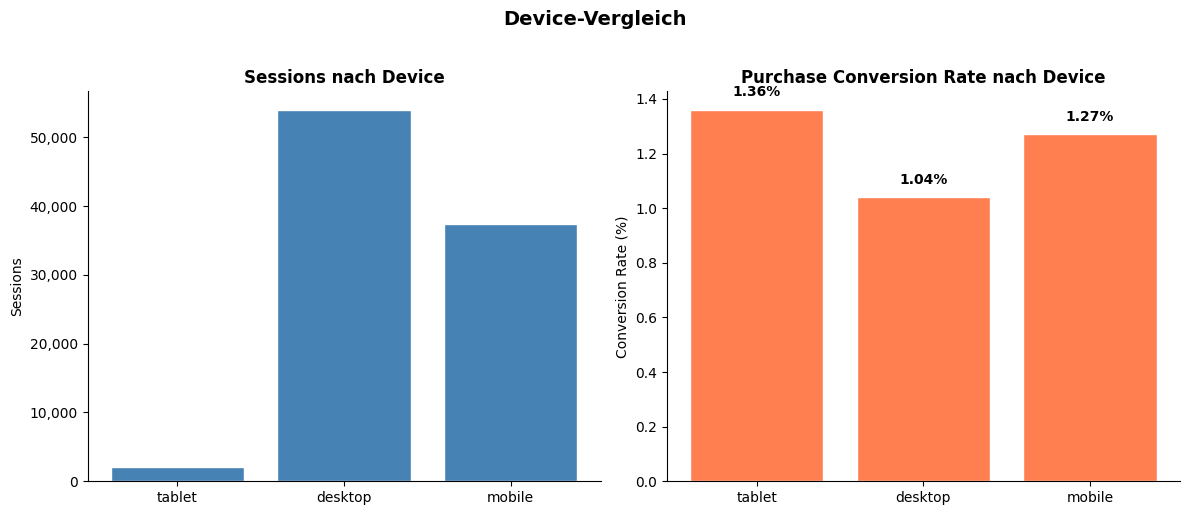

In [ ]:
# --- Device Conversion Vergleich ---
df_dev_pd = df_device.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sessions nach Device
axes[0].bar(df_dev_pd['device_category'], df_dev_pd['sessions'], color='steelblue', edgecolor='white')
axes[0].set_title('Sessions nach Device', fontweight='bold')
axes[0].set_ylabel('Sessions')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].spines[['top', 'right']].set_visible(False)

# Conversion Rate nach Device
bars = axes[1].bar(df_dev_pd['device_category'], df_dev_pd['conversion_rate_pct'],
                   color='coral', edgecolor='white')
for bar, val in zip(bars, df_dev_pd['conversion_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.2f}%", ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Purchase Conversion Rate nach Device', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Device-Vergleich', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('device_chart.png', dpi=150, bbox_inches='tight')
plt.show()

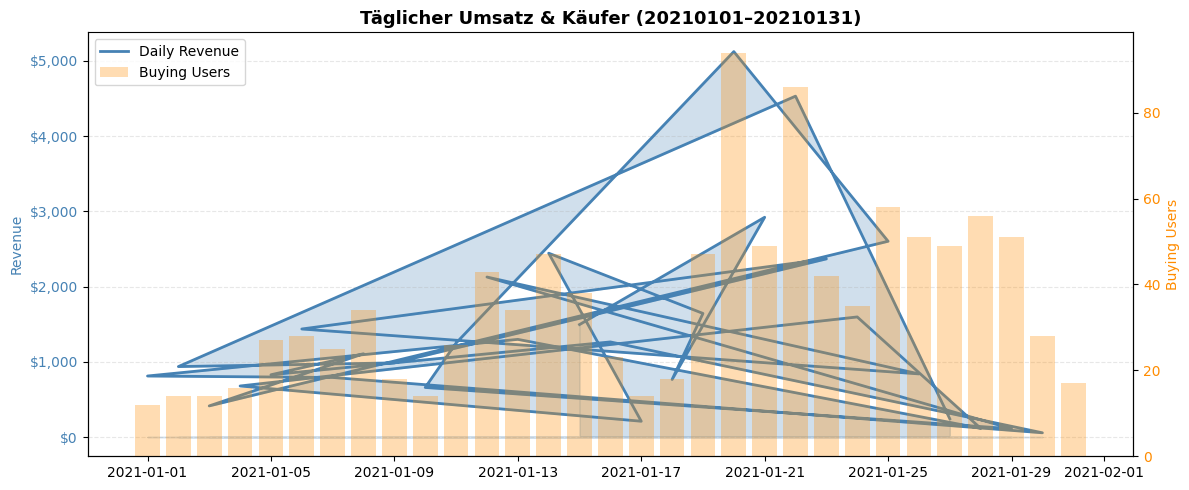

In [ ]:
# --- Täglicher Umsatz & Käufer (Dual-Axis Chart) ---
df_daily_pd = df_daily.to_pandas()
df_daily_pd['event_date'] = pd.to_datetime(df_daily_pd['event_date'])

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.fill_between(df_daily_pd['event_date'], df_daily_pd['daily_revenue'],
                 alpha=0.25, color='steelblue')
ax1.plot(df_daily_pd['event_date'], df_daily_pd['daily_revenue'],
         color='steelblue', linewidth=2, label='Daily Revenue')
ax1.set_ylabel('Revenue', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
ax2.bar(df_daily_pd['event_date'], df_daily_pd['buying_users'],
        alpha=0.3, color='darkorange', width=0.8, label='Buying Users')
ax2.set_ylabel('Buying Users', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_title(f'Täglicher Umsatz & Käufer ({DATE_START}–{DATE_END})',
              fontsize=13, fontweight='bold')
ax1.spines[['top']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('daily_revenue_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Zusammenfassung & nächste Schritte

### Was wir analysiert haben:

| Schritt | Frage | Query |
|---|---|---|
| Dataset-Überblick | Wie groß ist der Datensatz? | `df_overview` |
| Event Inventory | Welche Events gibt es? | `df_events` |
| Event Funnel | Wie oft passiert jeder Schritt? | `df_funnel_events` |
| User Funnel | Wie viele eindeutige User erreichen jeden Schritt? | `df_user_funnel` |
| Drop-off | Wo verlieren wir den größten Anteil? | `df_dropoff` |
| Device | Unterschiede nach Device-Typ | `df_device` |
| Land | Welche Länder konvertieren am besten? | `df_country` |
| Revenue | Umsatz, AOV, Tagestrend | `df_revenue`, `df_daily` |

### Mögliche nächste Schritte:

- **Session-Pfad Analyse** — Was tun User *zwischen* den Funnel-Schritten? Welche Seiten besuchen Abbrecher?
- **Cohort Analyse** — Wie verhalten sich neue vs. wiederkehrende User im Funnel?
- **Item-Level Analyse** — Welche Produkte treiben `add_to_cart` am meisten? Wo gibt es Abbrüche?
- **Traffic-Source Analyse** — Welcher Kanal (organic, paid, direct) hat die beste Conversion?
- **Checkout-Abbrecher** — Wer hat `begin_checkout` ausgelöst, aber nicht gekauft? Können wir segmentieren?